In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
dataA = pd.read_csv("data/TSPA.csv", sep=";", names=["x", "y", "z"]) 
dataB = pd.read_csv("data/TSPB.csv", sep=";", names=["x", "y", "z"])

In [35]:
def plotData(data, title="", withLabels=False):
    pos = {i: (row['x'], row['y']) for i, row in data.iterrows()}

    G_full = nx.complete_graph(len(data))
    nx.draw_networkx_nodes(G_full, pos, node_size=10)
    if withLabels:
        nx.draw_networkx_labels(G_full, pos)
    plt.title(title)

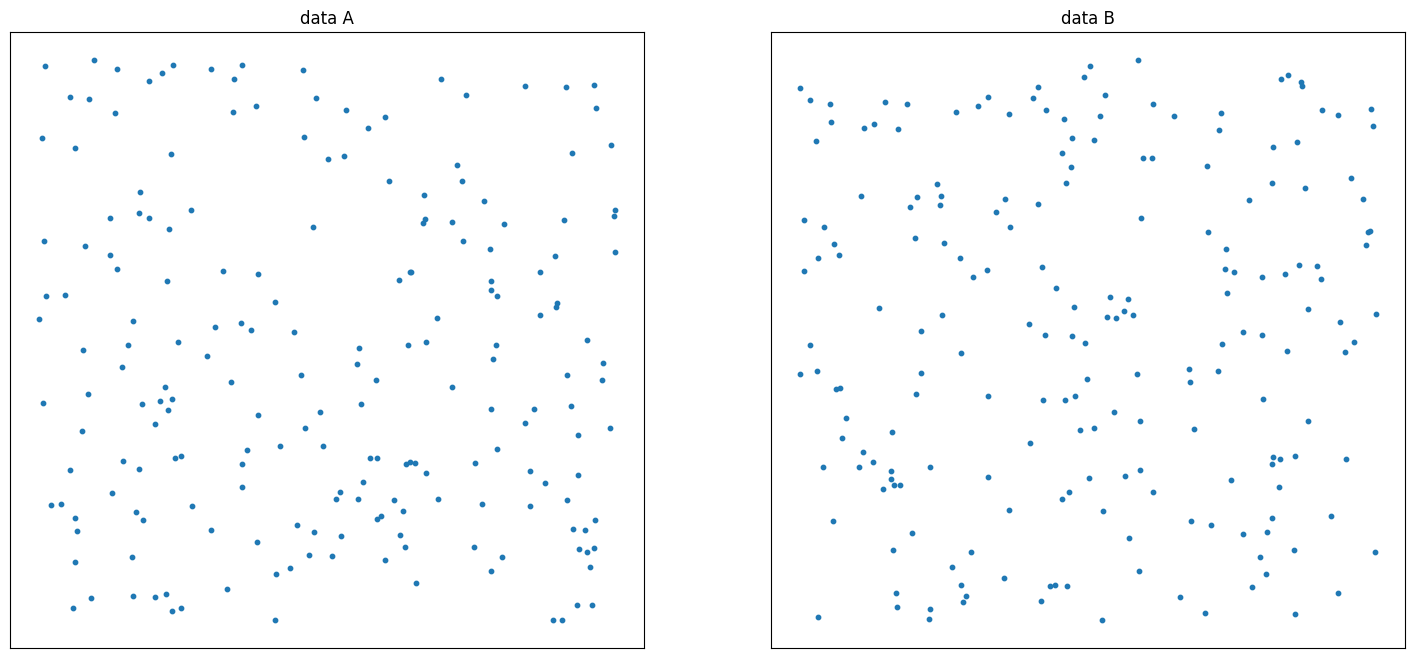

In [36]:
plt.subplots(1, 2, figsize=(18, 8))
plt.subplot(1, 2, 1)
plotData(dataA, title="data A")
plt.subplot(1, 2, 2)
plotData(dataB, title="data B")

In [5]:
solutionsPath = Path("data/solutions")

In [6]:
solutions = {}
for file_path in solutionsPath.glob("*.txt"):
    with open(file_path, "r") as file:
        solutions[file_path.name] = [int(file.strip()) for file in file.readlines()]

In [52]:
def plotSolution(data, name, cycle, withLabels=False):
    G_sol = nx.Graph()
    
    # Dodajemy wierzchołki
    G_sol.add_nodes_from(cycle)
    
    # Budujemy krawędzie z trasy (zamykamy cykl)
    edges = [(cycle[j], cycle[j+1]) for j in range(len(cycle)-1)]
    edges.append((cycle[-1], cycle[0])) # powrót do startu
    G_sol.add_edges_from(edges)

    pos = {i: (data['x'][i], data['y'][i]) for i in cycle}
    node_list = list(G_sol.nodes())
    colors = [data['z'][i] for i in node_list]
    
    # Rysowanie
    nodes = nx.draw_networkx_nodes(G_sol, pos, node_color=colors, cmap="coolwarm", node_size=10)
    nx.draw_networkx_edges(G_sol, pos)
    if withLabels:
        nx.draw_networkx_labels(G_sol, pos)
    plt.colorbar(nodes, orientation='horizontal', pad=0)
    plt.title(name)

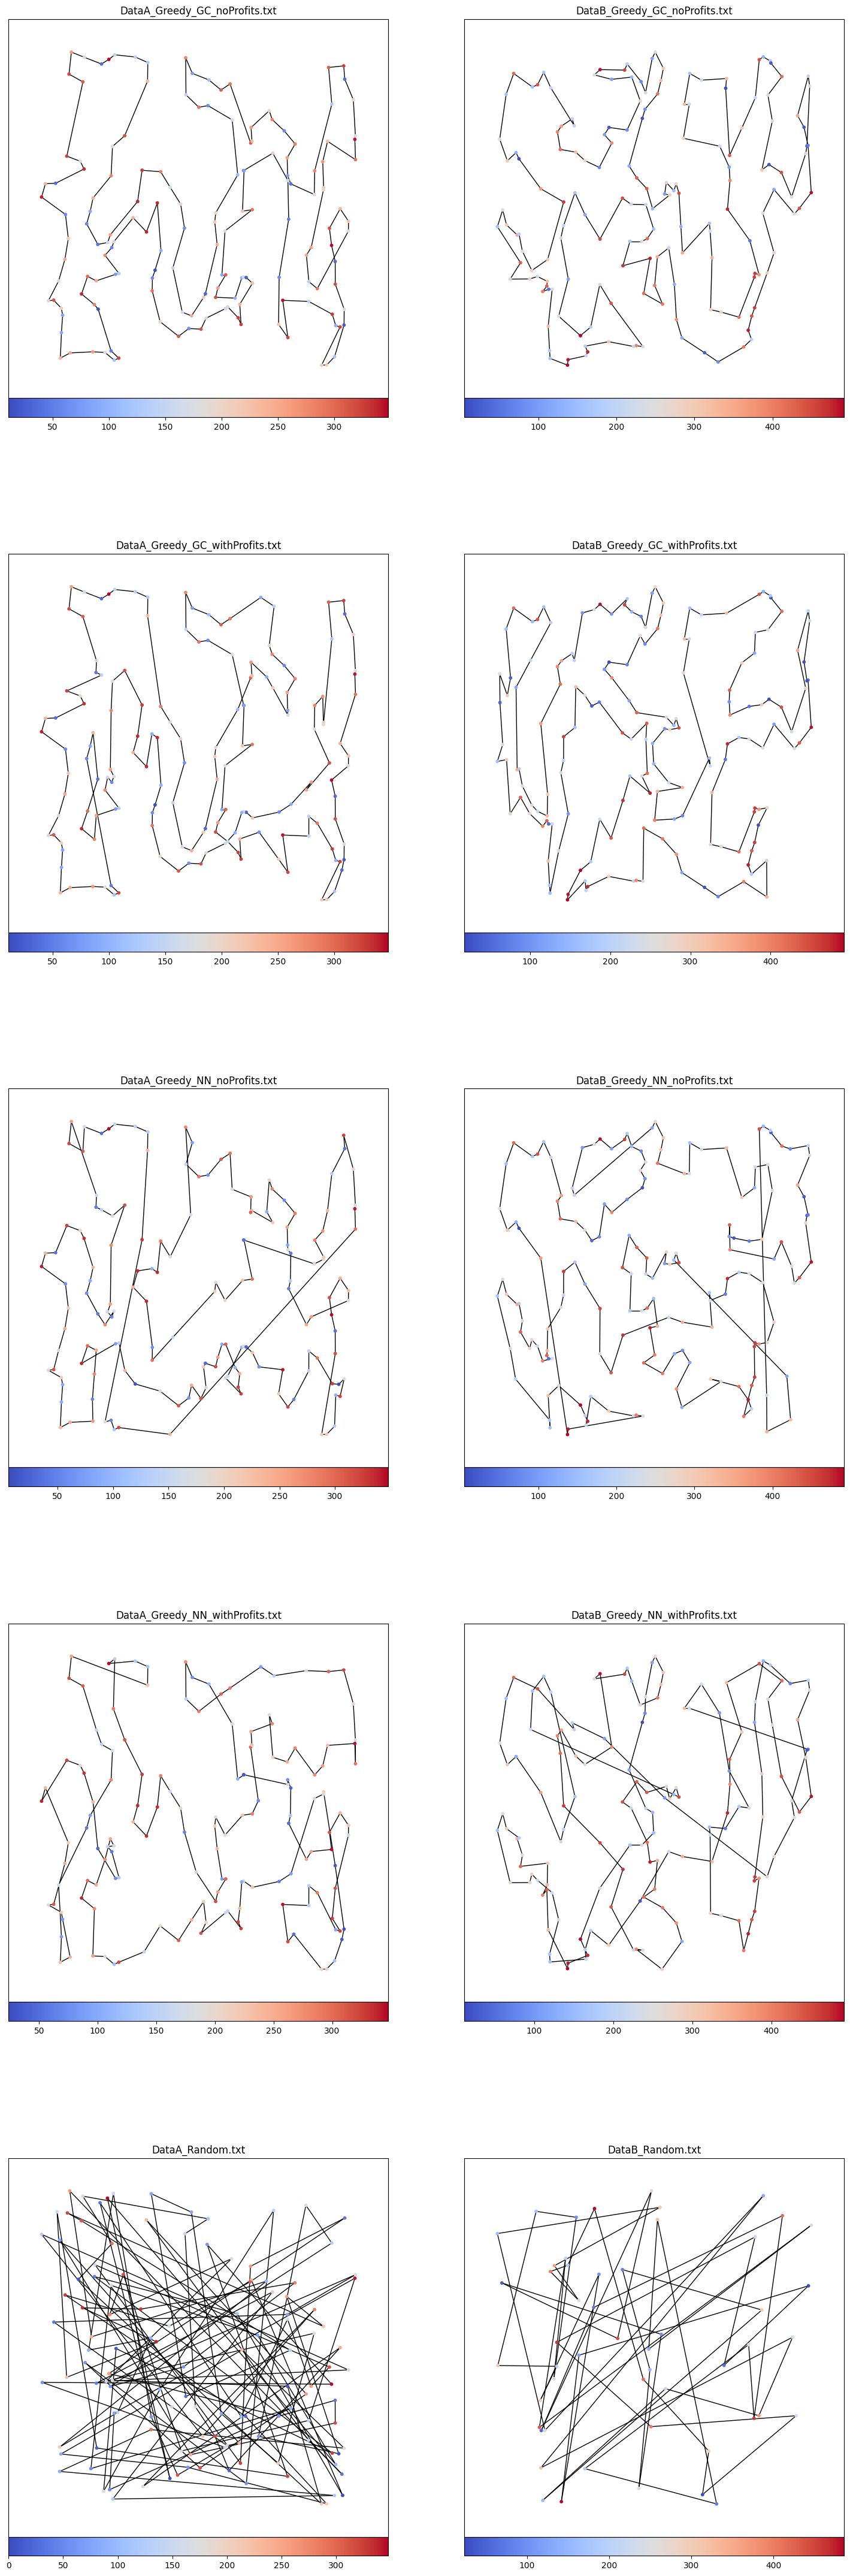

In [53]:
rows = len(solutions)//2
plt.subplots(rows, 2, figsize=(18, 8*rows  + 4*(rows-1)))
solutionPairs = list(solutions.items())
solutionsDataA = sorted([item for item in solutionPairs if item[0].startswith("DataA")], key=lambda x: x[0])
solutionsDataB = sorted([item for item in solutionPairs if item[0].startswith("DataB")], key=lambda x: x[0])
sortedSolutions = []
for a, b in zip(solutionsDataA, solutionsDataB):
    sortedSolutions.append(a)
    sortedSolutions.append(b)
for i, (name, cycle) in enumerate(sortedSolutions):
    plt.subplot(rows, 2, i+1)
    plotSolution(dataA if name[:5] == "DataA" else dataB, name, cycle)